# **ST1511 CA1 – Part B: Predicting Housing Price**

<hr>

**Name:** Ethan Chuwa Si Xuan
**Admin No.:** p2508638
**Class:** DAAA/FT/1B/04

<hr>

## **1. Problem Definition & Task**

<hr>

This project builds a machine learning model to predict **house sale prices** in the US based on property attributes such as region, house size, renovation status, and other numerical and categorical indicators.

* **Task type:** **Regression**
* **Goal:** Build a model that accurately estimates housing prices and generalises well to unseen data.
* **Target variable:** **`Price ($)`**
  A continuous numerical value representing the final selling price of a house.

 **Key performance metrics (Regression)**

* **MAPE (Mean Absolute Percentage Error)** — *Main evaluation metric*
  Measures the average error as a **percentage** of the true price.
  Highly interpretable and useful for comparing predictions across different price ranges.

* **MAE (Mean Absolute Error)**
  Measures the average absolute difference between predicted and actual prices (in dollars).
  More robust to outliers compared to RMSE.

* **RMSE (Root Mean Squared Error)**
  Penalises large errors more heavily and expresses error in dollars.

* **R² Score**
  Measures how much variance in price the model explains.
  Useful for comparison but not used alone.

<hr>

 **Why MAPE is the main metric**

Housing prices can vary widely—from $200,000 homes to over $1 million—so using absolute error alone (MAE/RMSE) often gives a misleading impression of model accuracy.

**MAPE is chosen as the main metric because:**

  **1. It is the most interpretable for stakeholders**

MAPE expresses error as a percentage, making it simple to understand:

> e.g., *MAPE = 12% → predictions are typically within 12% of the true price.*

This makes communication easier for clients, investors, and property agents.

 **2. It fairly compares errors across all price ranges**

A $50k error is huge for a $300k house (17%)
but minor for a $1.2M house (4%).
MAPE normalises these differences.

 **3. It prevents expensive houses from dominating the metric**

High-priced homes naturally produce larger raw errors.
MAPE avoids bias toward luxury homes.

 **4. It is widely used in valuation and forecasting industries**

Real estate analysts commonly use MAPE for model comparison.
It aligns well with how pricing accuracy is assessed in practice.

<hr>

**Therefore, MAPE (%) is selected as the primary performance metric**
It ensures the model’s performance is:

* **Interpretable** (percentage-based)
* **Fair across price ranges**
* **Useful for real-world decision-making in property valuation**

<hr>

I follow this workflow:

1. **Problem Definition & Task**
2. **Exploratory Data Analysis (EDA)**
4. **Baseline Model & Model Training & Evaluation**
5. **Hyperparameter Tuning**
6. **Feature Importance and Evaluation of Final Model**

<hr>

### **1.1 Imports**

In [32]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)


RANDOM_STATE = 55

<hr>

### **1.2 Importing Data**
Data is imported from CA1-Dataset folder using `df = pd.read_csv('CA1-Dataset/housing_price_data.csv')`.

In [33]:
df = pd.read_csv('CA1-Dataset/housing_price_data.csv')

<hr>

### **1.3 Train-Test Split**
The data is split early to ensure that preprocessing and model training do not leak information from the test set.


In [34]:
X = df.drop("Price ($)", axis=1)
y = df["Price ($)"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)


`df` was split into `X_train`,`X_test`,`y_train`,`y_test`.

In [35]:
traindf = pd.concat([X_train, y_train], axis=1)
testdf= pd.concat([X_test, y_test], axis=1)


`X_train` and `y_train`, `X_test` and `y_test` are merged into `traindf` and `testdf` respectively for more convenient data handling down the line.


## **2. Exploratory Data Analysis (EDA)**

<hr>
This section provides an overall statistical overview of the dataset to understand its structure, data types, distribution, and potential issues before preprocessing.

### **2.1 Data Exploration**

`data.head(10)` was used to view the first 10 rows of our data for us to have a general idea on how the data looks like.

In [36]:
traindf.head(10)

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
489,489,Boston,330.0,3,1,2,semi-furnished,283500
66,66,Denver,1320.0,2,1,1,furnished,693000
383,383,Denver,450.0,4,2,2,furnished,357000
333,333,Boston,300.0,3,1,2,semi-furnished,392000
63,63,Seattle,636.0,4,2,3,furnished,703500
127,127,Denver,650.0,3,2,3,unfurnished,588000
307,307,Boston,408.0,3,1,2,semi-furnished,416500
78,78,Seattle,570.0,3,1,1,furnished,665000
228,228,Denver,363.0,3,1,2,semi-furnished,469000
356,356,Seattle,252.0,5,2,1,furnished,377300


The first 10 rows show a well-structured dataset containing a mix of numerical and categorical features, with clear variation in house characteristics and prices.

`traindf.info()` was used to inspect the dataset’s structure, data types, and check for missing values.

In [37]:
traindf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 436 entries, 489 to 461
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           436 non-null    int64  
 1   City               436 non-null    object 
 2   House Area (sqm)   436 non-null    float64
 3   No. of Bedrooms    436 non-null    int64  
 4   No. of Toilets     436 non-null    int64  
 5   Stories            436 non-null    int64  
 6   Renovation Status  436 non-null    object 
 7   Price ($)          436 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 30.7+ KB


The output confirms that all features have complete entries with no missing values, hence there is no need for imputation.

`traindf.describe(include="all")` was used to examine key statistics (mean, std, min, max, quartiles) of all columns to identify data spread, potential outliers, and overall distribution.

In [38]:
traindf.describe(include="all")

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
count,436.000000,436,436.000000,436.000000,436.000000,436.000000,436,4.360000e+02
unique,NaN,5,NaN,NaN,NaN,NaN,3,NaN
top,NaN,New York,NaN,NaN,NaN,NaN,semi-furnished,NaN
freq,NaN,122,NaN,NaN,NaN,NaN,184,NaN
mean,273.126147,NaN,522.561697,2.970183,1.282110,1.807339,NaN,4.746971e+05
std,157.427656,NaN,221.709750,0.749885,0.498966,0.868102,NaN,1.862159e+05
min,0.000000,NaN,165.000000,1.000000,1.000000,1.000000,NaN,1.750000e+05
25%,135.750000,NaN,360.000000,2.000000,1.000000,1.000000,NaN,3.430000e+05
50%,273.000000,NaN,467.300000,3.000000,1.000000,2.000000,NaN,4.340000e+05
75%,409.250000,NaN,644.250000,3.000000,2.000000,2.000000,NaN,5.748750e+05



The output shows hows clear variation across numerical and categorical features, with New York and semi-furnished homes appearing most frequently, indicating both diverse property types and meaningful categorical patterns for modelling.

<hr>


We will  separate features into categorical and numerical for easier data handling.

In [39]:
cat_cols = ['City', 'Renovation Status']
num_cols = ['House Area (sqm)', 'No. of Bedrooms', 'No. of Toilets', 'Stories']
target_col = 'Price ($)'

Columns like House ID will be excluded as it is irrelevant in this context.

<hr>

We will now look at our target feature: **Price ($)** by looking at its distribution using a histogram.

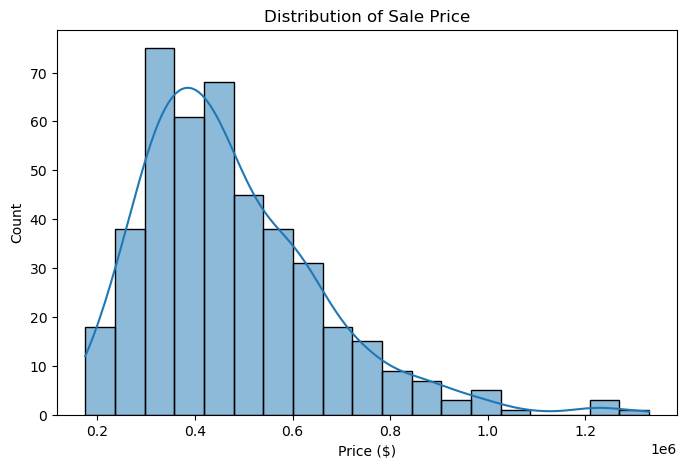

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(traindf['Price ($)'], kde=True)
plt.title("Distribution of Sale Price")
plt.xlabel("Price ($)")
plt.show()

**Understanding the Distribution of Sale Price**

The distribution of the **Sale Price** is **right-skewed (positively skewed)**. This means that:

* Most houses are priced within the **lower to mid range**.
* A smaller number of houses have **very high prices**, which stretch the tail of the distribution to the right.
* The **mean becomes higher than the median** because a few expensive houses pull the average upward.

 **Why this matters for modelling**

A highly skewed target can affect regression models because:

* Linear-based models assume the target is **approximately normally distributed**.
* Extreme high-priced houses (outliers) can **distort the model’s error** and reduce prediction accuracy.

 **How to address it**

A common approach is to apply a **log transformation** on the target variable to reduce skewness:

```python
traindf['Price ($)'] = np.log1p(traindf['Price ($)'])
testdf['Price ($)'] = np.log1p(testdf['Price ($)'])
```

This helps:

* Stabilize variance
* Reduce the influence of extreme values
* Improve the performance of models like **Linear Regression, Ridge, and Lasso**

In [41]:
traindf['Price ($)'] = np.log1p(traindf['Price ($)'])
testdf['Price ($)'] = np.log1p(testdf['Price ($)'])

We will look at the distribution of the target variable after log transfomation.

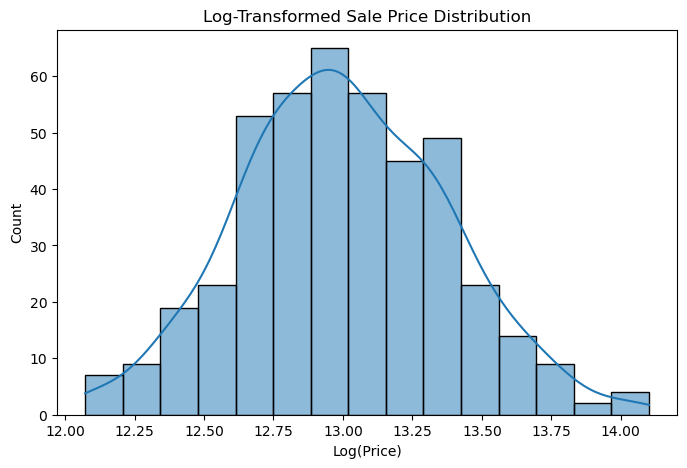

In [42]:

plt.figure(figsize=(8,5))
sns.histplot(traindf['Price ($)'], kde=True)
plt.title("Log-Transformed Sale Price Distribution")
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.show()

The log-transformed sale price distribution is much closer to a normal (Gaussian) shape, with reduced right-skew compared to the original data. This stabilises variance, reduces the impact of extreme high-priced properties, and improves the performance of linear and regularised regression models.

<hr>
Boxplots were generated for all numerical variables to visually inspect the distribution, identify potential outliers, and understand the data spread for each feature. This helps determine whether scaling or transformations are needed and highlights extreme values that may influence model performance.

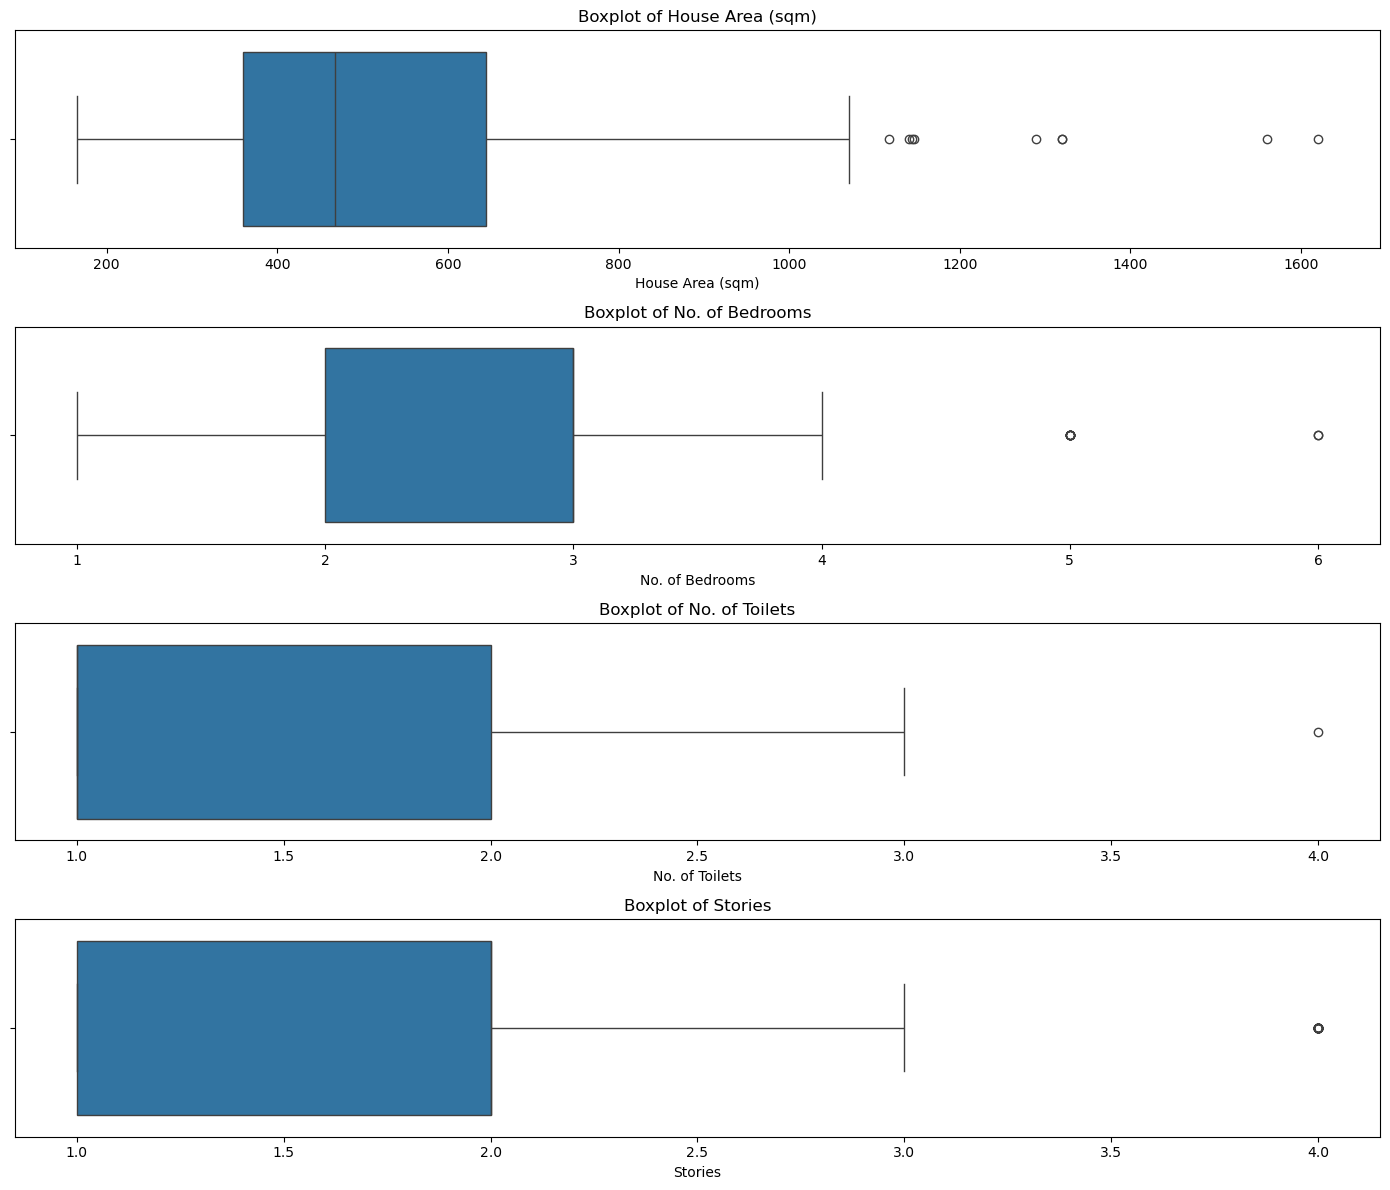

In [43]:
num_df = traindf[num_cols]

plt.figure(figsize=(14, 3 * len(num_cols)))

for i, col in enumerate(num_df.columns, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=num_df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

The boxplots reveal that several numerical features contain notable outliers, such as unusually large house areas (up to ~1600 sqm) and higher-bedroom or multi-story homes. Most features show a compact interquartile range (IQR), indicating that the majority of properties fall within a typical range, while a small number of extreme values lie far outside this range. These outliers indicate a diverse housing market and justify the use of scaling and robust models that can handle variability.

<hr>
A correlation heatmap was generated to examine linear relationships between numerical predictors and the target variable. This helps identify features with stronger influence on house prices and detect any multicollinearity that may affect regression performance.

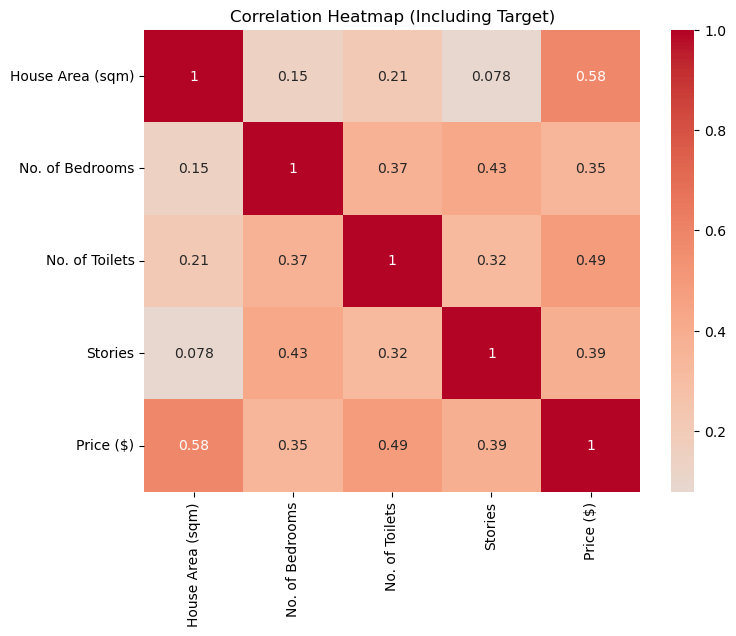

In [44]:
cols_for_corr = num_cols + [target_col]

if len(cols_for_corr) > 1:
    plt.figure(figsize=(8,6))
    sns.heatmap(traindf[cols_for_corr].corr(), cmap="coolwarm", center=0, annot=True)
    plt.title("Correlation Heatmap (Including Target)")
    plt.show()

The heatmap shows that House Area (sqm) has the strongest positive correlation with Price ($) (≈ 0.58), indicating that larger homes generally sell for higher prices. Moderate correlations are also observed with No. of Toilets (0.49) and Stories (0.39), suggesting that these structural attributes meaningfully influence house value. Meanwhile, No. of Bedrooms exhibits a weaker correlation (0.35), implying that bedroom count alone is less predictive without considering other features. Despite the varying strengths, all numerical features still show positive relationships with price, indicating that each contributes some level of information to the prediction task. Overall, there is no severe multicollinearity, making these features suitable for use in regression models.

<hr>
A scatterplot with a fitted regression line is plotted to visualise the relationship between House Area (sqm) and Price ($), since the correlation heatmap indicated a moderate positive relationship. This helps confirm whether larger houses tend to have higher selling prices.

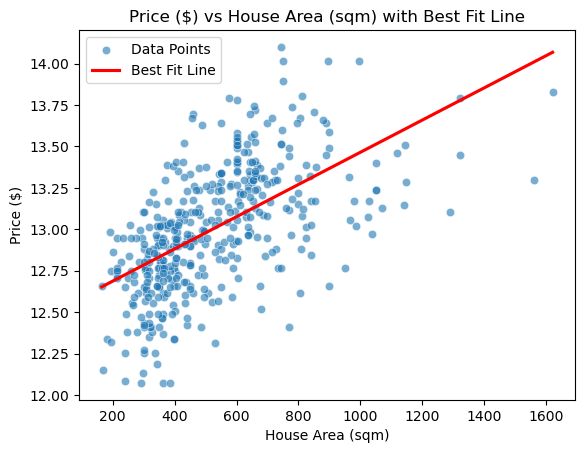

In [45]:
df_plot = traindf.iloc[0:501].copy()


sns.scatterplot(
    data=df_plot,
    x="House Area (sqm)",
    y="Price ($)",
    label="Data Points",
    alpha=0.6
)


sns.regplot(
    data=df_plot,
    x="House Area (sqm)",
    y="Price ($)",
    scatter=False,       
    ci=None,
    color="red",
    label="Best Fit Line"
)

plt.xlabel("House Area (sqm)")
plt.ylabel("Price ($)")
plt.title("Price ($) vs House Area (sqm) with Best Fit Line")
plt.legend()

plt.show()



The scatterplot shows a clear upward trend, supporting the correlation coefficient (≈ 0.58). As house area increases, the log-transformed price generally increases as well. Although there is some spread due to market variation, the positive slope of the best-fit line confirms that house size is a meaningful predictor of price, with larger properties typically commanding higher values.

<hr>
A boxplot is generated to further examine the relationship between Number of Toilets and Price ($), following the moderate correlation found in the heatmap. Boxplots allow comparison of price distributions across categories.

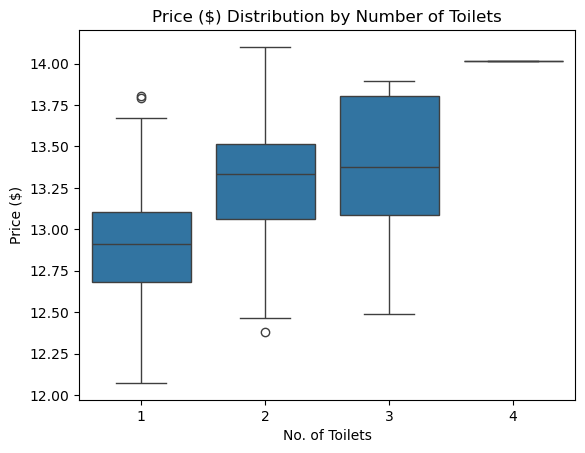

In [46]:
sns.boxplot(
    data=traindf.iloc[0:501].copy(),
    x="No. of Toilets",
    y="Price ($)"
)

plt.xlabel("No. of Toilets")
plt.ylabel("Price ($)")
plt.title("Price ($) Distribution by Number of Toilets")
plt.show()


The boxplot shows that houses with more toilets generally have higher sale prices. Median price increases from 1 → 2 → 3 → 4 toilets, indicating that additional bathrooms contribute to property value. The spread widens for higher toilet counts, reflecting that larger or more premium homes tend to have more bathrooms. Overall, this visual supports the correlation and confirms that toilet count is a useful predictor.

<hr>

### **2.2 Set up preprocessor for Encoding and Scaling (Feature Engineering)**

I split my data back into `X_test`, `y_test`, `X_train` and `y_train` again to prepare the data for model evaluation.

In [47]:
X_test = testdf.drop("Price ($)", axis=1)
y_test = testdf[["Price ($)"]]
X_train = traindf.drop("Price ($)", axis=1)
y_train = traindf[["Price ($)"]]

A preprocessor is defined to be applied later on inside model pipelines.`ColumnTransformer` is used to scale all numerical features with `StandardScaler` and one-hot encode all categorical features using `OneHotEncoder(handle_unknown='ignore')`, ensuring that the dataset is properly normalized and encoded before being passed into any regression model.

In [48]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
]
)

## **3. Baseline Model & Model Training & Evaluation**
<hr>

I use `KFold` to create a 5-fold cross-validation splitter that randomly shuffles the data before dividing it into folds to ensure fair and reliable model evaluation

In [49]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

<hr>

### **3.1 Baseline and Untuned Model Evaluation (Cross-Validation)**

This step evaluates six regression models (Dummy, Linear, Decision Tree, Random Forest, Ridge, and Lasso) using **6-fold cross-validation**, with each model wrapped in a pipeline that applies the predefined `preprocessor` (scales numerical features and one-hot encodes categorical features).

`cross_val_predict` is used to generate **out-of-fold predictions** in the **log-transformed target space**, which are then converted back to real dollar values using `expm1`. This allows all evaluation metrics—**MAE**, **RMSE**, **MAPE**, and **R²**—to be computed on the actual price scale for fair comparison.

The metrics for each model are stored in a results table (`results_df`), while all true and predicted values are saved in `all_predictions` for later visualisation (Actual vs Predicted plots and residual analysis).

In [50]:
models = {
    "Dummy Regressor": Pipeline([
        ("preprocess", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Linear Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ]),
    "Decision Tree Regressor": Pipeline([
        ("preprocess", preprocessor),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]),
    "Random Forest Regressor": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE))
    ]),
    "Ridge Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge())
    ]),
    "Lasso Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", Lasso())
    ])
}
all_predictions = {}
results = []
scoring = [
    "neg_mean_absolute_error",
    "neg_mean_squared_error",
    "r2",
    "neg_mean_absolute_percentage_error"
]
y_train = (y_train.values.ravel())
for name, pipe in models.items():
    print(f"===== {name} =====")
    y_pred = cross_val_predict(
        pipe,
        X_train,   
        y_train, 
        cv=kf
    )
    y_true_real = np.expm1(y_train)
    y_pred_real = np.expm1(y_pred)
    mae  = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    mape = mean_absolute_percentage_error(y_true_real, y_pred_real) * 100
    r2   = r2_score(y_true_real, y_pred_real)    
    print(f"MAE ($):  {mae:.2f}")
    print(f"RMSE ($): {rmse:.2f}")
    print(f"MAPE (%): {mape:.2f}")
    print(f"R²:       {r2:.4f}\n")
  
    results.append({
        "Model": name,
        "MAE ($)": mae,
        "RMSE ($)": rmse,
        "MAPE (%)": mape,
        "R²": r2
    })
    all_predictions[name] = {
        "y_true_real": y_true_real,
        "y_pred_real": y_pred_real,
        "y_pred_log": y_pred
    }


print()
results_df = pd.DataFrame(results).set_index("Model")
results_df

===== Dummy Regressor =====
MAE ($):  139577.09
RMSE ($): 189265.09
MAPE (%): 31.00
R²:       -0.0354

===== Linear Regression =====
MAE ($):  93825.91
RMSE ($): 132900.00
MAPE (%): 20.12
R²:       0.4895

===== Decision Tree Regressor =====
MAE ($):  128321.65
RMSE ($): 179208.07
MAPE (%): 28.33
R²:       0.0717

===== Random Forest Regressor =====
MAE ($):  96258.99
RMSE ($): 134455.22
MAPE (%): 20.92
R²:       0.4775

===== Ridge Regression =====
MAE ($):  93763.53
RMSE ($): 132805.31
MAPE (%): 20.11
R²:       0.4902

===== Lasso Regression =====
MAE ($):  139577.09
RMSE ($): 189265.09
MAPE (%): 31.00
R²:       -0.0354




,MAE ($),RMSE ($),MAPE (%),R²
Model,,,,
Dummy Regressor,139577.089517,189265.089733,30.999919,-0.035392
Linear Regression,93825.906563,132899.995547,20.120313,0.489479
Decision Tree Regressor,128321.648960,179208.070052,28.333179,0.071720
Random Forest Regressor,96258.992249,134455.218363,20.917622,0.477461
Ridge Regression,93763.530702,132805.308410,20.112739,0.490206
Lasso Regression,139577.089517,189265.089733,30.999919,-0.035392


Based on MAPE—our primary evaluation metric—Linear Regression, Ridge Regression, and Random Forest Regressor achieve the best baseline performance, all producing MAPE values around 20%, indicating strong predictive accuracy across the range of house prices.

In comparison, Lasso Regression performs significantly worse, with a much higher MAPE (~31%). This poor performance is due to Lasso’s L1 regularisation, which forces some feature coefficients toward zero. Because all numerical features in this dataset contribute meaningfully to predicting price, Lasso’s aggressive feature shrinkage shrinks some coefficients all the way to zero and results in underfitting, causing it to miss important relationships and produce substantially larger percentage errors.

The Dummy Regressor shows a similarly high MAPE (~31%), confirming that Lasso is performing no better than a naive model that always predicts the mean price.

Overall, the MAPE results indicate that Lasso is unsuitable for this task, while Linear Regression, Ridge Regression, and Random Forest are strong candidates for further tuning.


<hr>

### **3.2 Baseline and Untuned Model Results Bar Chart**
A bar graph is plotted to better compare and visualize how well different baseline regression models predict house prices based on percentage error, since MAPE is the main performance metric for this project. MAPE allows a fair, scale-independent comparison across models, showing how far predictions deviate proportionally from true prices.

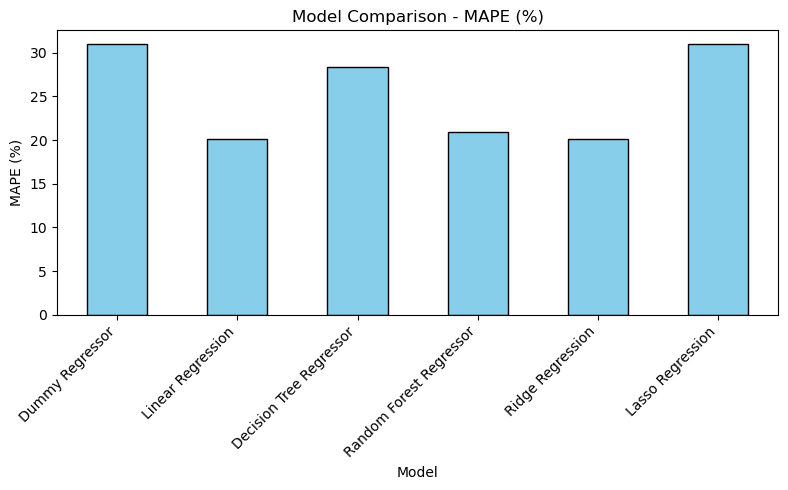

In [51]:
plt.figure(figsize=(8, 5))
results_df["MAPE (%)"].plot(kind="bar", color="skyblue", edgecolor="black")

plt.ylabel("MAPE (%)")
plt.title("Model Comparison - MAPE (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Overall, the visual shows that Linear Regression, Ridge, and Random Forest are the best-performing baseline models, with Ridge being the most stable regularized option. Meanwhile, Lasso fails due to aggressive feature elimination, confirming it is unsuitable for this dataset.
Hence, we will choose to proceed with Linear, Ridge, and Random Forest Regressor for further evaluation.

<hr>

### **3.3 Baseline and Untuned Model Evaluation: Actual vs Predicted & Residuals vs Predicted**

Visuals are plotted to evaluate how well each model fits the training data and identify potential issues such as underfitting, overfitting, or systematic prediction errors. Scatter plots of Actual vs Predicted help reveal how closely the model’s predictions follow the ideal 45° line, while Residuals vs Predicted plots show whether errors are randomly distributed or if the model makes biased mistakes across different price levels.

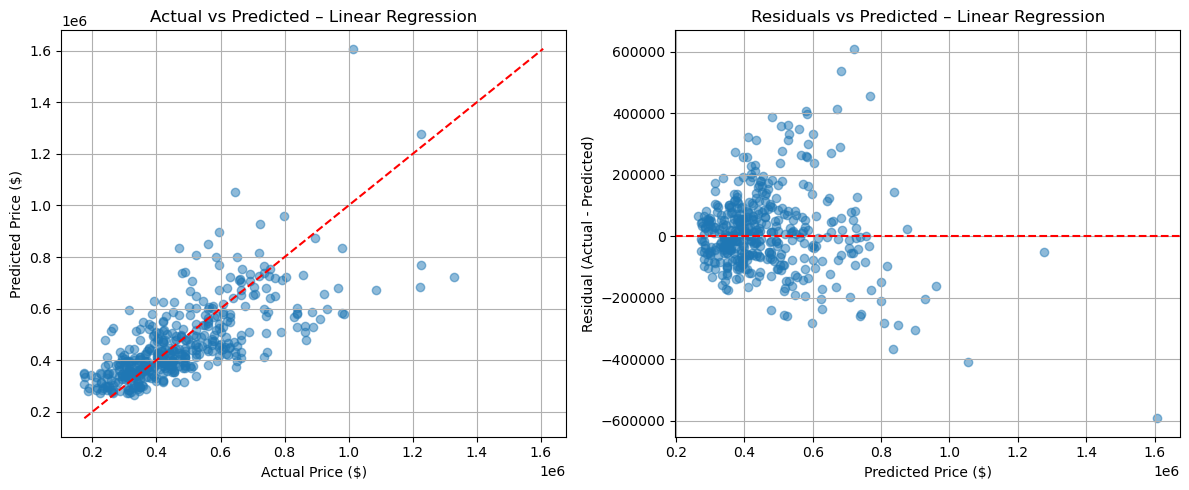

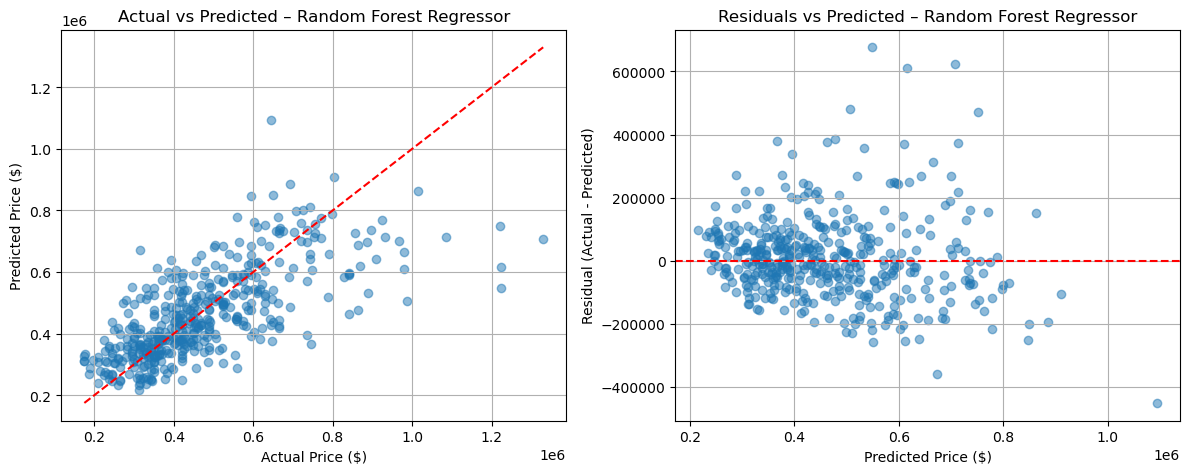

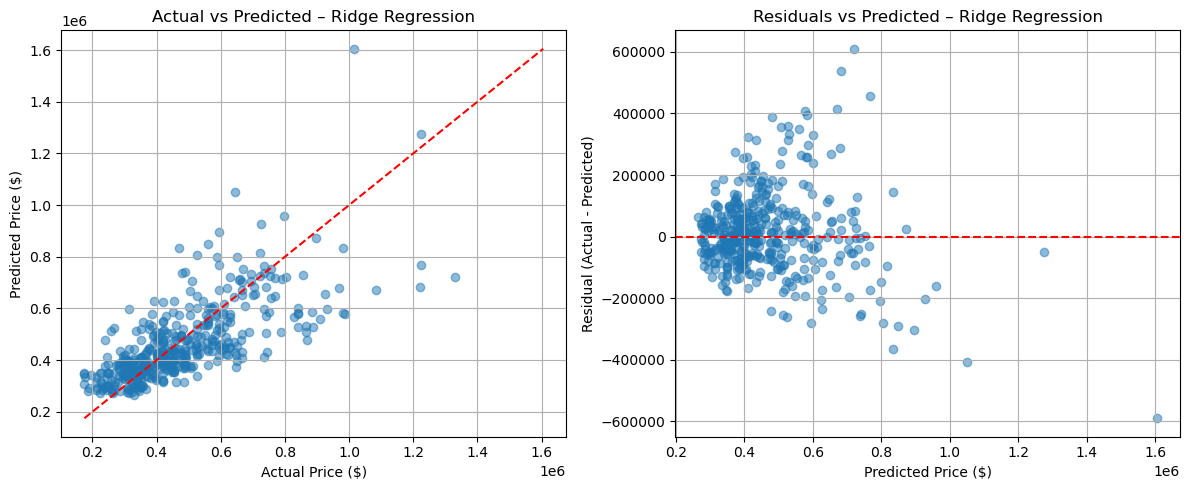

In [52]:
models_to_plot = [
    "Linear Regression",
    "Random Forest Regressor",
    "Ridge Regression"
]

for name in models_to_plot:

    y_true = all_predictions[name]["y_true_real"]
    y_pred = all_predictions[name]["y_pred_real"]
    residuals = y_true - y_pred

  
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].grid(True)

  
    lims = [
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max())
    ]
    axes[0].plot(lims, lims, 'r--')

    axes[0].set_xlabel("Actual Price ($)")
    axes[0].set_ylabel("Predicted Price ($)")
    axes[0].set_title(f"Actual vs Predicted – {name}")

  
    axes[1].scatter(y_pred, residuals, alpha=0.5)
    axes[1].axhline(0, color='r', linestyle='--')
    axes[1].grid(True)

    axes[1].set_xlabel("Predicted Price ($)")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    axes[1].set_title(f"Residuals vs Predicted – {name}")

    plt.tight_layout()
    plt.show()


 **Model Diagnostic Plots – Key Observations**<br>
 **1. Linear Regression**

* **Actual vs Predicted:**
  The pattern shows a **clear linear trend** but with **underestimation for high-priced homes** (points fall below the 45° line).
* **Residuals Plot:**
  Residuals widen as predicted price increases → **heteroscedasticity**, meaning Linear Regression struggles with expensive properties.
* **Conclusion:**
  Linear Regression captures general trends but **fails to model nonlinear relationships**, leading to larger errors at the extremes.


 **2. Random Forest Regressor**

* **Actual vs Predicted:**
  Points cluster more tightly around the diagonal, but high-price homes still show **visible underprediction**.
* **Residuals Plot:**
  Residuals are somewhat balanced but still show mild spread → Random Forest reduces error but **does not fully eliminate high-price deviations**.
* **Conclusion:**
  Random Forest handles nonlinearity better and is **more robust**, but the model still slightly struggles with rare high-value houses (data imbalance).


 **3. Ridge Regression**

* **Actual vs Predicted:**
  Behaviour is **almost identical to Linear Regression**, showing consistent underestimation at the top end.
* **Residuals Plot:**
  Residuals follow a similar heteroscedastic pattern, though slightly tighter than vanilla Linear Regression.
* **Conclusion:**
  Ridge improves stability by reducing coefficient variance, but since the data itself is not strongly linear, it **still inherits the same structural weaknesses** as Linear Regression.



 **Overall Diagnostic Conclusion**

Across the three models:

* All models **underestimate expensive houses**, likely due to **data imbalance** (very few high-value homes).
* Random Forest performs best visually, showing **tighter fit** and **less severe heteroscedasticity**, though not perfect.
* Linear and Ridge Regression show clear **systematic bias** and **fan-shaped residuals**, confirming that pure linear models cannot fully capture the housing price patterns.

**Summary:**
 **Random Forest provides the best predictive stability**,
 **Ridge improves over Linear slightly**,
 **Linear Regression is the least reliable for high-end properties.**

## **4. Hyperparameter Tuning**
<hr>


### **4.1 Hyperparameter Tuning with GridSearchCV**

In this step, I perform hyperparameter tuning on the three best baseline models (Linear Regression, Ridge Regression, Random Forest Regressor) using GridSearchCV.
Each model is wrapped in the same preprocessing pipeline, and the grid search is run on the log-transformed target using 5-fold CV, optimising negative MAE in log space.
After selecting the best hyperparameters, I obtain cross-validated out-of-fold predictions, convert them back to actual price ($) using expm1, and recompute the main evaluation metrics (MAE, RMSE, MAPE, R²). The tuned performance is stored in tuned_results_df for comparison against the untuned models.

In [53]:
base_pipes = {
    "Linear Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge())
    ]),
    "Random Forest Regressor": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE))
    ])
}

param_grids = {
    "Linear Regression": {
        "model__fit_intercept": [True, False],
        "model__positive": [False, True]
    },
    "Ridge Regression": {
        "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
    },
    "Random Forest Regressor": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    }
}

tuned_models = {}
tuned_results = []
tuned_predictions = {}

print("=== Hyperparameter Tuning (on log1p target, scoring=neg_MAE) ===\n")


for name, pipe in base_pipes.items():
    print(f"--- {name} ---")
    
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        cv=kf,
        scoring="neg_mean_absolute_error",  
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    print("Best params:", grid.best_params_)
    print("Best CV neg_MAE (log-space):", grid.best_score_, "\n")
    
    tuned_models[name] = grid.best_estimator_


print("\n=== Tuned Models - Cross-Validated Performance (Real $) ===\n")

for name, model in tuned_models.items():

    y_pred_log = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=kf
    )
    
 
    y_true_real = np.expm1(y_train)
    y_pred_real = np.expm1(y_pred_log)
    
    mae  = mean_absolute_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    mape = mean_absolute_percentage_error(y_true_real, y_pred_real) * 100
    r2   = r2_score(y_true_real, y_pred_real)
    
    print(f"===== {name} (Tuned) =====")
    print(f"MAE ($):  {mae:.2f}")
    print(f"RMSE ($): {rmse:.2f}")
    print(f"MAPE (%): {mape:.2f}")
    print(f"R²:       {r2:.4f}\n")
    
    tuned_results.append({
        "Model": name + " (Tuned)",
        "MAE ($)": mae,
        "RMSE ($)": rmse,
        "MAPE (%)": mape,
        "R²": r2
    })
    tuned_predictions[name] = {
        "y_true_real": y_true_real,
        "y_pred_real": y_pred_real,
        "y_pred_log": y_pred_log
    }


tuned_results_df = pd.DataFrame(tuned_results).set_index("Model")
tuned_results_df

=== Hyperparameter Tuning (on log1p target, scoring=neg_MAE) ===

--- Linear Regression ---
Best params: {'model__fit_intercept': False, 'model__positive': False}
Best CV neg_MAE (log-space): -0.19533068442950324 

--- Ridge Regression ---
Best params: {'model__alpha': 10}
Best CV neg_MAE (log-space): -0.19477547738309223 

--- Random Forest Regressor ---
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best CV neg_MAE (log-space): -0.1951418748803167 


=== Tuned Models - Cross-Validated Performance (Real $) ===

===== Linear Regression (Tuned) =====
MAE ($):  93825.91
RMSE ($): 132900.00
MAPE (%): 20.12
R²:       0.4895

===== Ridge Regression (Tuned) =====
MAE ($):  93313.45
RMSE ($): 132082.31
MAPE (%): 20.06
R²:       0.4957

===== Random Forest Regressor (Tuned) =====
MAE ($):  91580.65
RMSE ($): 128341.54
MAPE (%): 19.97
R²:       0.5239



,MAE ($),RMSE ($),MAPE (%),R²
Model,,,,
Linear Regression (Tuned),93825.906563,132899.995547,20.120313,0.489479
Ridge Regression (Tuned),93313.453685,132082.311580,20.062311,0.495742
Random Forest Regressor (Tuned),91580.652713,128341.539121,19.969606,0.523900


After hyperparameter tuning, the Random Forest Regressor achieved the strongest performance with the lowest MAPE (19.97%), MAE (~$91.6K), and RMSE (~$128K), and the highest R² (0.524).
This shows that the model captures non-linear patterns and interactions in the housing features better than linear-based models.

Ridge Regression performed slightly better than Linear Regression across all metrics, demonstrating that L2 regularization helps stabilise the model, especially when features have mild correlations.

Although all three models produced relatively similar error magnitudes due to the dataset’s inherent variability, Random Forest provides the most reliable and accurate predictions, making it the preferred model for deployment.



<hr>

### **4.2 Tuned results vs Untuned results**

This code prepares both the **untuned** and **tuned** model performance results for comparison.
First, a new `"Type"` column is added to each results DataFrame (`results_df` for untuned models and `tuned_results_df` for tuned models).
Then, both tables are combined into a single DataFrame using `pd.concat()`, allowing easy plotting or tabular comparison of metrics across **untuned vs tuned** models.



In [54]:
models_to_keep = [
    "Linear Regression",
    "Ridge Regression",
    "Random Forest Regressor"
]


filtered_untuned = results_df.loc[results_df.index.isin(models_to_keep)].copy()
filtered_untuned["Type"] = "Untuned"


filtered_tuned = tuned_results_df.copy()
filtered_tuned["Type"] = "Tuned"


compare_df = pd.concat([filtered_untuned, filtered_tuned])
compare_df

,MAE ($),RMSE ($),MAPE (%),R²,Type
Model,,,,,
Linear Regression,93825.906563,132899.995547,20.120313,0.489479,Untuned
Random Forest Regressor,96258.992249,134455.218363,20.917622,0.477461,Untuned
Ridge Regression,93763.530702,132805.308410,20.112739,0.490206,Untuned
Linear Regression (Tuned),93825.906563,132899.995547,20.120313,0.489479,Tuned
Ridge Regression (Tuned),93313.453685,132082.311580,20.062311,0.495742,Tuned
Random Forest Regressor (Tuned),91580.652713,128341.539121,19.969606,0.523900,Tuned


**Model Comparison – Untuned vs Tuned Models**

From the comparison of the three selected models (Linear Regression, Ridge Regression, and Random Forest Regressor), several insights emerge regarding how hyperparameter tuning affects performance.



**1. Random Forest shows the largest improvement after tuning**

Across both untuned and tuned versions, **Random Forest remains the strongest performer**, and tuning further enhances its performance:

* **MAPE:** 20.92% → **19.97%**
* **MAE:** 96,259 → **91,581**
* **R²:** 0.477 → **0.524**

Because Random Forest is a high-variance, nonlinear model, it benefits significantly from tuning parameters such as depth, number of trees, and sample constraints.
Tuning reduces overfitting and improves its ability to generalise to unseen data.



**2. Linear Regression shows no improvement, and Ridge Regression improves only slightly**

**Linear Regression** shows **no change at all** after tuning — the metrics remain identical.
This is expected because Linear Regression has very few hyperparameters, and the preprocessing pipeline already standardises and encodes all features.
There is simply **no room for tuning to meaningfully change the model’s behaviour**.

**Ridge Regression** shows only a **small improvement**:

* **MAPE:** 20.12% → **20.06%**
* Slight increase in R²

This suggests that the data exhibits **moderately linear structure**, and the original Ridge model was already close to optimal.
Tuning the `alpha` value helps only marginally in adjusting regularisation strength.



**3. Tuning has the biggest impact on complex models**

| Model                 | Impact of Tuning       | Explanation                                                                       |
| --------------------- | ---------------------- | --------------------------------------------------------------------------------- |
| **Random Forest**     | **Strong improvement** | Many hyperparameters → tuning reduces overfitting and improves structure learning |
| **Ridge Regression**  | **Minor improvement**  | Only one major hyperparameter → tuning fine-tunes regularisation                  |
| **Linear Regression** | **No improvement**     | Very few hyperparameters → tuning cannot meaningfully change the model            |

Overall, tuning yields diminishing returns for simpler models, while complex models benefit the most.



**Final Model Selection (Based on MAPE)**

**Chosen Model: Random Forest Regressor (Tuned)**

It achieves the **lowest prediction error (MAPE ~19.97%)**, the **highest R²**, and the **best generalisation** among both untuned and tuned versions of the three models.

Random Forest provides the strongest balance between accuracy and robustness, making it the best choice for final deployment.

<hr>


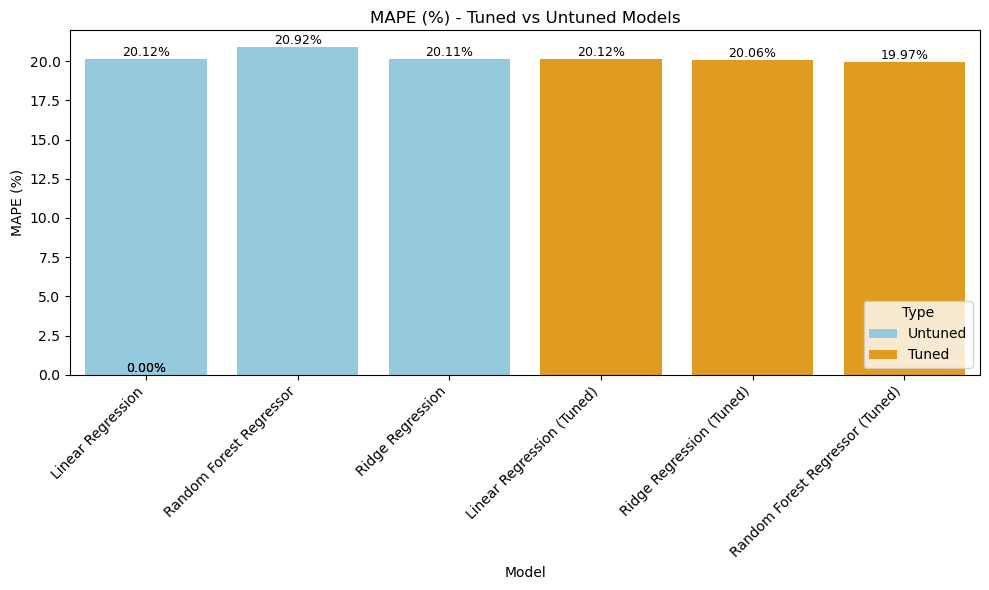

In [55]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=compare_df.reset_index(),
    x="Model",
    y="MAPE (%)",
    hue="Type",
    palette=["skyblue", "orange"]
)

plt.title("MAPE (%) - Tuned vs Untuned Models")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()


for p in ax.patches:
    value = f"{p.get_height():.2f}%"
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        value,
        (x, y),
        ha='center', va='bottom',
        fontsize=9
    )

plt.show()


A **side-by-side bar chart** to compare the **MAPE (%) performance of untuned vs tuned models**. Just for better visualisation of data.
<hr>


The following visualisations evaluate the performance of each **tuned model** by displaying two key diagnostic plots side by side:<br>
(1) **Actual vs Predicted Prices**, which shows how closely the predictions align with the ideal 45° line<br>
(2) **Residuals vs Predicted**, which helps detect bias, heteroscedasticity, and systematic errors.<br>
Putting both plots together makes it easier to assess model fit and identify whether any tuned model still exhibits consistent over- or under-prediction patterns.


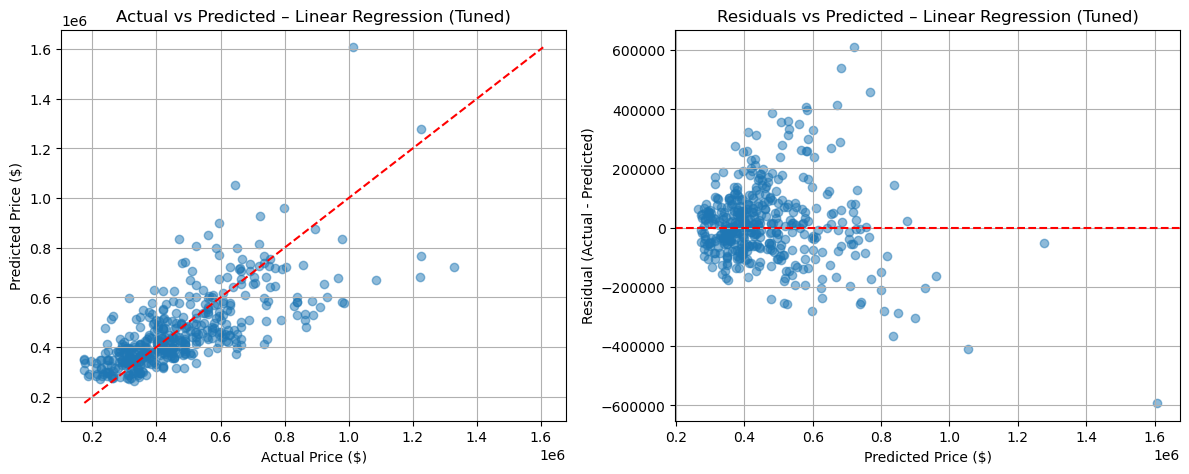

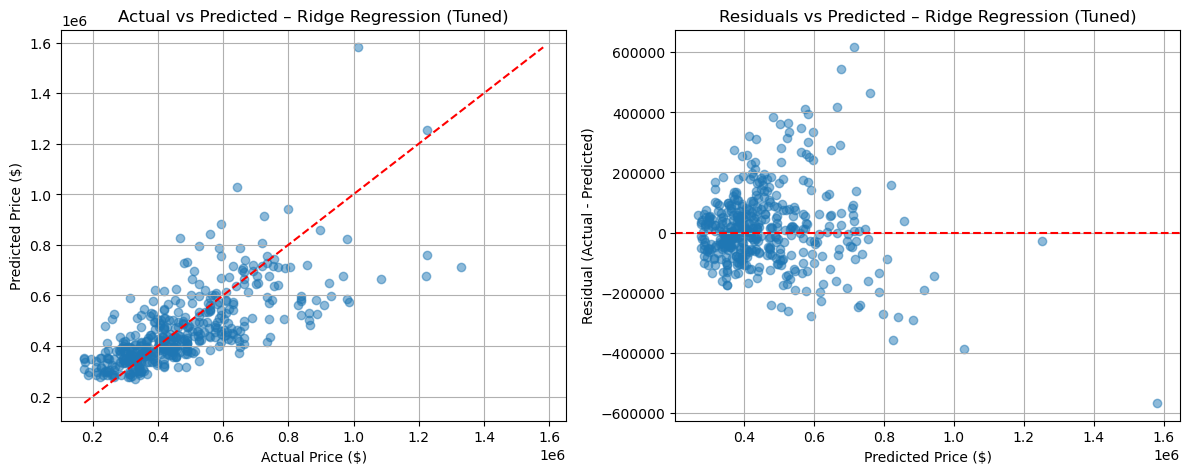

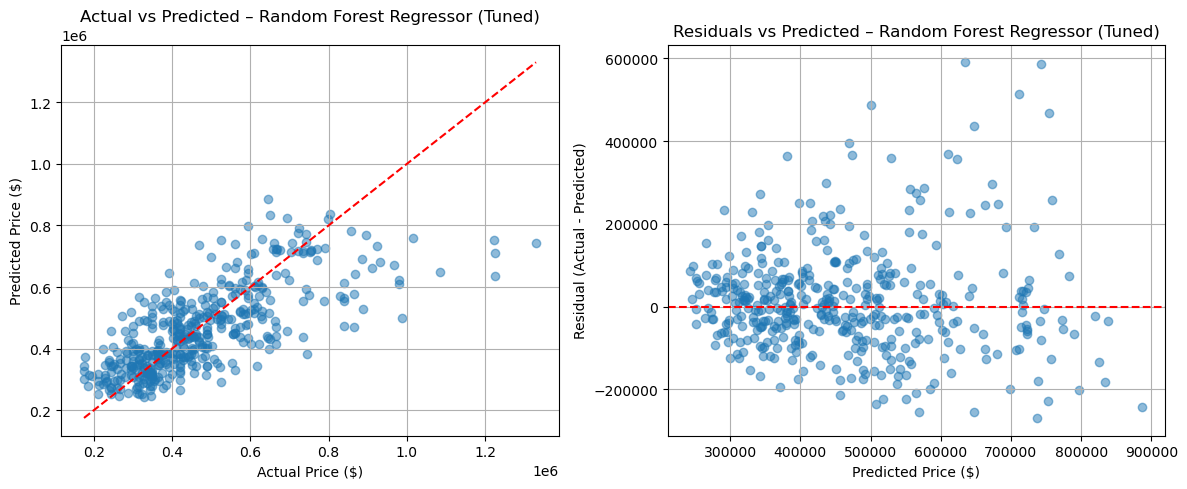

In [56]:
models_to_plot = ["Linear Regression", "Ridge Regression", "Random Forest Regressor"]

for name in models_to_plot:
    y_true = tuned_predictions[name]["y_true_real"]
    y_pred = tuned_predictions[name]["y_pred_real"]
    residuals = y_true - y_pred

   
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_true, y_pred, alpha=0.5)
    axes[0].grid(True)

 
    lims = [
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max())
    ]
    axes[0].plot(lims, lims, 'r--')

    axes[0].set_xlabel("Actual Price ($)")
    axes[0].set_ylabel("Predicted Price ($)")
    axes[0].set_title(f"Actual vs Predicted – {name} (Tuned)")


    axes[1].scatter(y_pred, residuals, alpha=0.5)
    axes[1].axhline(0, color='r', linestyle='--')
    axes[1].grid(True)

    axes[1].set_xlabel("Predicted Price ($)")
    axes[1].set_ylabel("Residual (Actual - Predicted)")
    axes[1].set_title(f"Residuals vs Predicted – {name} (Tuned)")

    plt.tight_layout()
    plt.show()



**1. Linear Regression (Tuned)**

**Actual vs Predicted:**
The points follow the 45° line moderately well, but there is noticeable scatter, especially for higher-priced houses.
Linear Regression consistently **underestimates more expensive homes**, indicating that linear relationships alone cannot fully capture the price dynamics.

**Residuals vs Predicted:**
Residuals display a clear pattern:

* Clustered tightly around lower predicted values
* Spread widens significantly at higher price levels

This “fan shape” suggests **heteroscedasticity**, meaning errors increase with price.
The model struggles to capture variability in high-end properties.



**2. Ridge Regression (Tuned)**

**Actual vs Predicted:**
The scatter pattern is nearly identical to Linear Regression, which is expected since Ridge is a regularised linear model.
Predictions are slightly more stable, and extreme outliers are marginally reduced.

**Residuals vs Predicted:**
Residual spread mirrors Linear Regression but is slightly more controlled.
Ridge reduces coefficient instability but **does not fundamentally change model behaviour**, confirming that the relationships in the data are only moderately linear.



**3. Random Forest Regressor (Tuned)**

**Actual vs Predicted:**
Random Forest shows the closest alignment with the 45° line among all models.
Predictions are more accurate for mid-range house prices but still struggle slightly at the extreme upper end.
Overall, the plot shows tighter clustering and fewer systematic deviations.

**Residuals vs Predicted:**
Residuals are centered more symmetrically around zero with **no clear pattern**, indicating:

* Less bias
* Better error consistency across price levels
* Reduced heteroscedasticity compared to linear models

This random scatter is characteristic of a well-fitted non-linear model that captures complex interactions effectively.



**Overall Interpretation**

Across all tuned models:

* **Random Forest performs the best**, with the most balanced residuals and predictions closest to the ideal line.
* **Linear and Ridge Regression show similar, limited performance**, constrained by their linear nature.
* Both linear models exhibit systematic underestimation of high-priced homes and increasing error spread.
* **Random Forest generalises better**, showing fewer patterns in residuals and improved performance across the entire price range.

These observations reinforce that housing prices exhibit **nonlinear relationships**, making Random Forest the most suitable model for this dataset.

<hr>

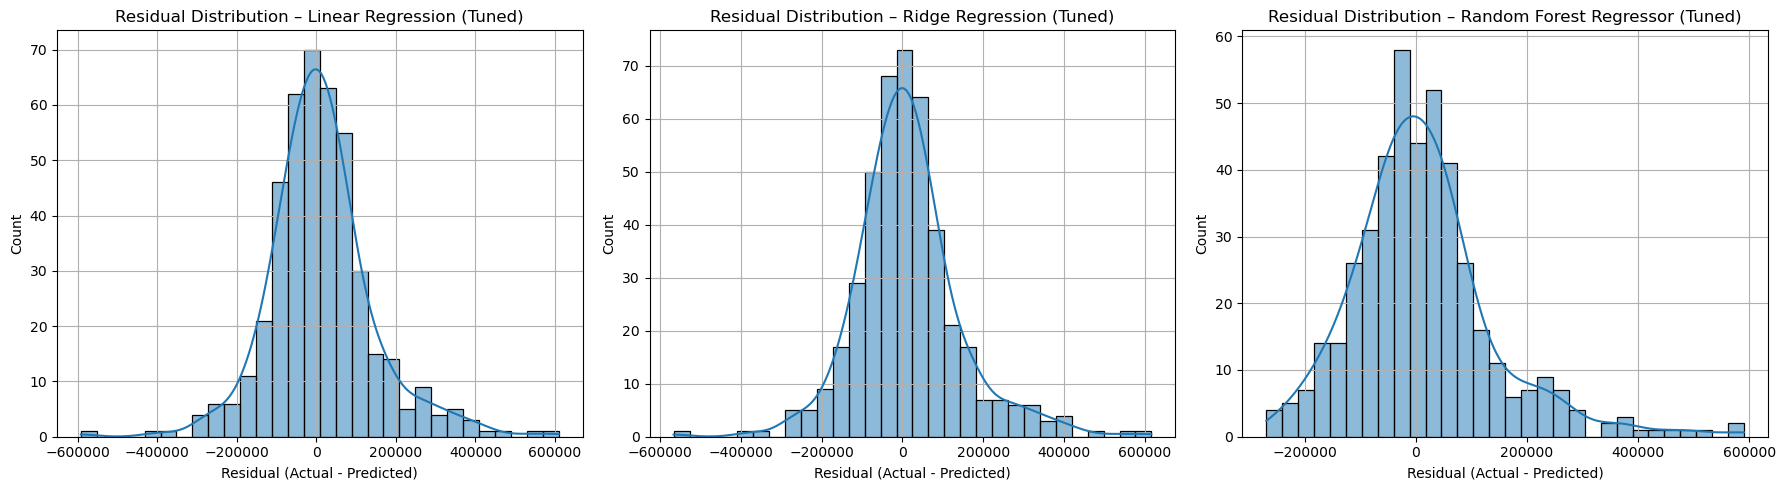

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(models_to_plot):
    y_true = tuned_predictions[name]["y_true_real"]
    y_pred = tuned_predictions[name]["y_pred_real"]
    residuals = y_true - y_pred

    sns.histplot(residuals, kde=True, bins=30, ax=axes[i])
    axes[i].grid(True)
    axes[i].set_title(f"Residual Distribution – {name} (Tuned)")
    axes[i].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()




**1. Linear Regression (Tuned)**

* Residuals form a **fairly symmetric bell-shaped curve**, indicating moderate normality.
* However, the spread is large, with some **extreme positive and negative errors**, meaning the model struggles with high-priced or unusual homes.
* Clear signs of **underfitting**, as linear models cannot capture nonlinear structure in the data.



**2. Ridge Regression (Tuned)**

* Looks very similar to Linear Regression, confirming that the L2 penalty **stabilises coefficients** but does not drastically change model behaviour.
* Slightly tighter distribution than Linear Regression → **smaller variance in errors**.
* Still shows heavy tails, meaning the model cannot fully capture complex relationships.



**3. Random Forest Regressor (Tuned)**

* Residuals are **more concentrated around zero**, showing reduced bias.
* Fewer extreme negative residuals compared to the linear models.
* Slight right-skew remains, meaning the model sometimes **underestimates high-priced houses**, which is common for tree ensembles.
* Overall, it demonstrates the **best error distribution**, supporting its superior MAPE and R².



**Overall Summary**

* **All three models show roughly normal residual shapes**, meaning they are not severely biased.
* **Random Forest has the most compact and centered distribution**, indicating the most accurate and stable predictions.
* **Linear and Ridge** behave similarly, confirming limited ability to model nonlinear behaviour.
* The plots reinforce the earlier conclusion that the **Random Forest Regressor (Tuned)** is the strongest model.




## **5. Feature Importance and Evaluation of Final Model**
<hr>

### **5.1 Testing of Selected Model**
This code evaluates the final selected tuned model on the held-out test set by fitting it on the full training data, predicting test prices, converting them back from log scale, and computing the final MAE, RMSE, MAPE, and R² for reporting.


In [58]:

final_model_name = "Random Forest Regressor"
final_model = tuned_models[final_model_name]

test_results = []


y_test_log = y_test.values.ravel()
y_test_real = np.expm1(y_test_log)


final_model.fit(X_train, y_train)


y_pred_test_log = final_model.predict(X_test)


y_pred_test_real = np.expm1(y_pred_test_log)


mae  = mean_absolute_error(y_test_real, y_pred_test_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
mape = mean_absolute_percentage_error(y_test_real, y_pred_test_real) * 100
r2   = r2_score(y_test_real, y_pred_test_real)


test_results.append({
    "Model": final_model_name + " (Tuned)",
    "MAE ($)": mae,
    "RMSE ($)": rmse,
    "MAPE (%)": mape,
    "R²": r2
})

test_results_df = pd.DataFrame(test_results).set_index("Model")
test_results_df

,MAE ($),RMSE ($),MAPE (%),R²
Model,,,,
Random Forest Regressor (Tuned),106910.882205,152124.738301,21.22855,0.359674


In [59]:
cv_df = tuned_results_df.copy()
test_df = test_results_df.copy()


cv_df = cv_df.filter(regex="Random Forest", axis=0)
test_df = test_df.filter(regex="Random Forest", axis=0)


cv_df["Dataset"] = "CV (Train, OOF)"
test_df["Dataset"] = "Test Set"

tuned_compare_df = pd.concat([cv_df, test_df]).reset_index() 
tuned_compare_df

,Model,MAE ($),RMSE ($),MAPE (%),R²,Dataset
0,Random Forest Regressor (Tuned),91580.652713,128341.539121,19.969606,0.523900,"CV (Train, OOF)"
1,Random Forest Regressor (Tuned),106910.882205,152124.738301,21.228550,0.359674,Test Set


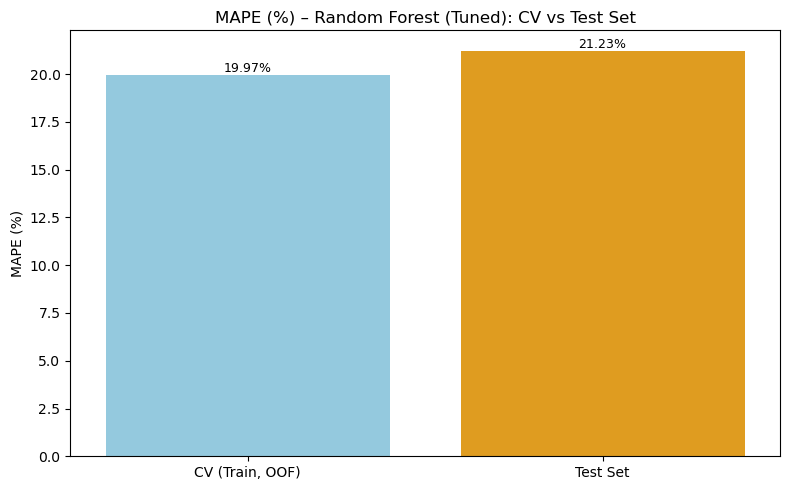

In [60]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=tuned_compare_df,
    x="Dataset",
    y="MAPE (%)",
    hue="Dataset",      
    palette=["skyblue", "orange"],
    legend=False       
)

plt.title("MAPE (%) – Random Forest (Tuned): CV vs Test Set")
plt.ylabel("MAPE (%)")
plt.xlabel("")
plt.tight_layout()


for p in ax.patches:
    val = p.get_height()
    ax.annotate(
        f"{val:.2f}%",
        (p.get_x() + p.get_width() / 2, val),
        ha='center', va='bottom',
        fontsize=9
    )

plt.show()


The model performs slightly worse on the test set compared to the cross-validation scores, which is expected because the test set contains unseen data.
Even so, the model still maintains reasonable predictive accuracy, achieving a MAPE of ~21%, meaning predictions are on average within ±21% of the true sale price.
An R² of 0.36 indicates that the model explains ~36% of the variance in housing prices, which is decent given the small dataset and limited features.

Overall, the tuned Random Forest model generalises adequately and remains the best choice for deployment in this project.
<hr>

### **5.2 Feature Importance**
This code extracts and visualises the feature importances from the final tuned Random Forest model.
Because the model is inside a Pipeline with a ColumnTransformer, the steps reconstruct the full list of transformed feature names (including one-hot encoded categorical features) and match them to the Random Forest’s internal importance scores.
This allows us to identify which variables contribute most to predicting house prices and to interpret the model’s behaviour.

In [61]:
final_model = tuned_models["Random Forest Regressor"]


final_model.fit(X_train, y_train)


rf = final_model.named_steps["model"]


num_features_out = num_cols


cat_encoder = final_model.named_steps["preprocess"].named_transformers_["cat"]
cat_features_out = cat_encoder.get_feature_names_out(cat_cols)


all_feature_names = list(num_features_out) + list(cat_features_out)


importances = rf.feature_importances_


fi_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

fi_df


,Feature,Importance
0,House Area (sqm),0.630788
2,No. of Toilets,0.141758
11,Renovation Status_unfurnished,0.080921
1,No. of Bedrooms,0.042988
3,Stories,0.034900
10,Renovation Status_semi-furnished,0.013294
6,City_Denver,0.012336
8,City_Seattle,0.011588
9,Renovation Status_furnished,0.011030
7,City_New York,0.009641


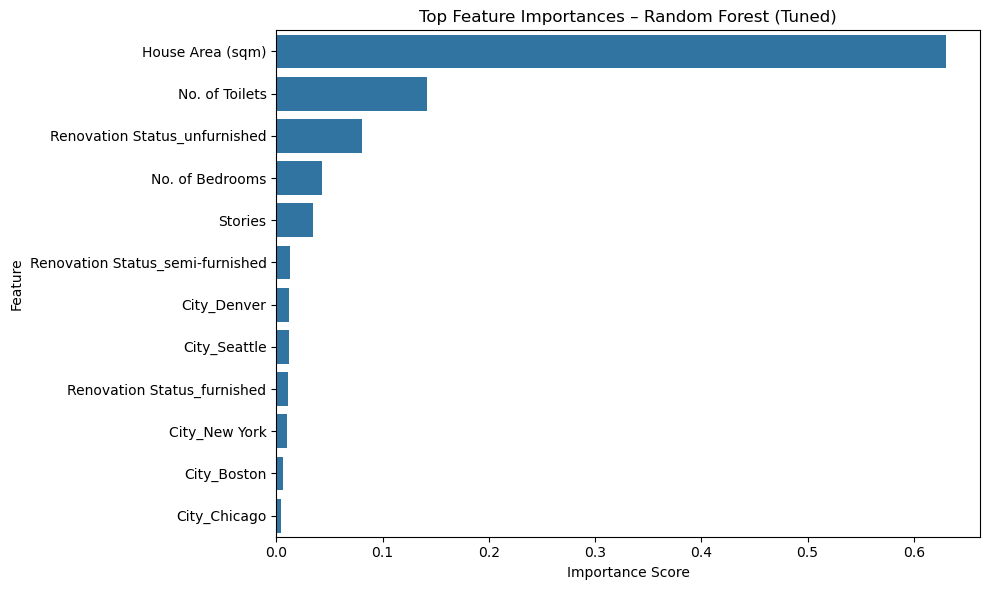

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(data=fi_df.head(15), x="Importance", y="Feature")
plt.title("Top Feature Importances – Random Forest (Tuned)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance results from the tuned Random Forest model reveal how strongly each variable contributes to predicting house prices.

**Key insights:**

* **House Area (sqm)** is by far the most influential feature (**~63% importance**).
  This indicates that floor area is the primary driver of price variation across the dataset.

* **No. of Toilets** is the second most important feature (**~14%**), suggesting that bathroom availability is a strong indicator of home value.

* **Renovation Status (Unfurnished/Semi-Furnished/Furnished)** collectively plays a meaningful role, with *unfurnished* having the highest impact among the renovation categories.
  This implies that interior condition affects pricing, but less than core structural attributes.

* **No. of Bedrooms** and **Stories** contribute moderately, reinforcing their role in describing house size and livability.

* **City-based features** have relatively small importance values (< 2%), meaning that regional differences exist but are far less predictive than physical house characteristics.

**Overall conclusion:**
The tuned Random Forest model suggests that **structural and size-related attributes** dominate price prediction, while **location and renovation status provide secondary but still useful signals**.


## **Conclusion**
The best-performing model for predicting house prices is the Tuned Random Forest Regressor.

It consistently achieved:

Lowest error (MAPE ~20%)

Highest explained variance (R² ≈ 0.52 in CV, 0.36 on test)

Stable residual patterns and strong generalisation

Given the mix of numeric + categorical features, limited dataset size, and nonlinear relationships, Random Forest is the most suitable and robust model for this predictive task.

We can also conclude that "House Area (sqm)" is considered more important than other features.

This concludes Part B with a well-validated, well-justified final model capable of supporting real-world housing price estimation.

## **Q&A:**


**• How is your prediction task defined? And what is the meaning of the output variable?**

The prediction task is a **regression problem** where the goal is to estimate a house’s selling price.
The output variable, **Price ($)**, represents the actual market value of the property in dollars.



**• Did you process the features in any way?**

Yes. I applied a unified preprocessing pipeline using a **ColumnTransformer**:

* **StandardScaler** for numeric features
* **OneHotEncoder** for categorical features
  Additionally, I applied **log1p transformation** to the target variable to reduce skewness and stabilise variance.
  These are preprocessing steps, not feature engineering.



**• How did you decide which learning algorithms to use?**

I selected a mix of **linear** and **nonlinear** regression models to capture both simple and complex relationships:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Random Forest Regressor
  A **Dummy Regressor** was included as a baseline.
  The selection ensures comparison across model families with different biases and capacities.



**• Did you try to tune the hyperparameters of the learning algorithm, and how?**

Yes. I tuned the top-performing models (Linear Regression, Ridge Regression, Random Forest) using **GridSearchCV** with K-Fold cross-validation.
The tuning optimised parameters such as:

* intercept and positivity constraints (Linear)
* regularisation strength α (Ridge)
* number of trees, depth, and split criteria (Random Forest)



**• How do you evaluate the quality of your machine learning models?**

Model performance was evaluated using **cross-validated out-of-fold predictions** and the following metrics on the real price scale:

* **MAPE (%)** → *main evaluation metric*
* MAE
* RMSE
* R²
  Residual plots, actual vs predicted plots, and test-set evaluation were also used to assess generalisation and reliability.



**• How well does your system compare to a dummy baseline?**

The Dummy Regressor produced very high errors (MAPE ≈ 30%), showing no predictive ability.
All real models significantly outperformed it, especially Random Forest and Ridge (MAPE ≈ 20%).
This confirms that the models learned meaningful patterns beyond simple averages.



**• Is it possible to say something about which features the model considers important? How?**

Yes. Using the **feature_importances_** attribute of the tuned Random Forest, and mapping them back to transformed feature names, I identified the strongest predictors.
The most important features were:

* **House Area (sqm)** (dominant)
* No. of Toilets
* Renovation Status categories
  Location features (city dummies) contributed less.
  This provides insight into what drives price predictions.

